In [1]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LATITUDE_FORMATTER, LONGITUDE_FORMATTER
import cftime
import datetime
from datetime import date
from matplotlib import pyplot
from matplotlib import colors
from matplotlib import font_manager
from matplotlib.cm import ScalarMappable
import matplotlib.colors as mcolors
import matplotlib.dates as mdates
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import numpy
import pandas
import xarray as xr

In [2]:
# Define Directories
Diri = '../ExtraTrack_Data/Output_Files_V7/'
Output_Diri = '../RCP_Figs/Analysis_Figs_V7.3.2/'

In [3]:
# Open File
def Open_File(File):
    DF = pandas.read_csv(File)
    DF = DF.drop("Unnamed: 0", axis=1)
    return (DF)

In [4]:
# Open Each File
def Files_Open(Model, Diri, Subset):
    Data_DF = Open_File(Diri+Model+'_Data_'+Subset+'_Output.csv')
    ET_DF = Open_File(Diri+Model+'_ET_'+Subset+'_Output.csv')
    Codes_DF = Open_File(Diri+Model+'_Codes_Output.csv')
# Edit Time Format
    Time_Cols = ["ET Begin Time", "ET Complete Time", "Trop Peak Time", "Peak Time", "Genesis Time", "Final Time"]
    for Col in Time_Cols:
        ET_DF[Col] = pandas.to_datetime(ET_DF[Col], errors="coerce")
    Data_DF["Time(Z)"] = pandas.to_datetime(Data_DF["Time(Z)"], errors="coerce")
    return (Data_DF, ET_DF, Codes_DF)

In [5]:
# Create Phase Distribution Bins
def Create_Bins(Min, Max, Bin_Width):
    Bins = numpy.arange(Min, Max+Bin_Width, Bin_Width)
    return (Bins)
Lon_Bins = Create_Bins(-100,20,5)
Lat_Bins = Create_Bins(0,60,5)

In [6]:
# Number of Years For Each Climate Scenario
Num_Years = numpy.array([90,93,93])

In [7]:
# Open Files
Control_Data, Control_ET, Control_Codes = Files_Open("Control", Diri, "SubsetB")
RCP45_Data, RCP45_ET, RCP45_Codes = Files_Open("RCP45", Diri, "SubsetB")
RCP85_Data, RCP85_ET, RCP85_Codes = Files_Open("RCP85", Diri, "SubsetB")

In [8]:
# Function For Creating Cumulative Distribution
def Cum_Dist(DF, Var, Min, Max, Bin_Width):
    Values = Create_Bins(Min, Max, Bin_Width)
    Count = numpy.zeros(len(Values))
    Length = len(DF[(DF[Var] >= Min) & (DF[Var] <= Max)])
    for i in range(len(Count)):
        Range = DF[(DF[Var] >= Min) & (DF[Var] <= Values[i])]
        Count[i] = len(Range)
    Density = Count / Length
    return (Values, Density)

In [9]:
# Function For Applying SLP Bounds
def ET_SLP_Bounds(Control_ET, RCP45_ET, RCP85_ET, Var, Low_Bound, Up_Bound):
    Control_ET_Bound = Control_ET[(Control_ET[Var] <= Up_Bound) & (Control_ET[Var] >= Low_Bound)]
    RCP45_ET_Bound = RCP45_ET[(RCP45_ET[Var] <= Up_Bound) & (RCP45_ET[Var] >= Low_Bound)]
    RCP85_ET_Bound = RCP85_ET[(RCP85_ET[Var] <= Up_Bound) & (RCP85_ET[Var] >= Low_Bound)]
    return (Control_ET_Bound, RCP45_ET_Bound, RCP85_ET_Bound)

In [10]:
# Create Function to Plot ET Cumulative Distributions
def ET_Cum_Dist_Plot(Control_ET, RCP45_ET, RCP85_ET, Var, Var_Label, Horiz, \
    Mins, Maxes, Bin_Widths, Label_Widths, Savefig, Figname):
    Fig = pyplot.figure(figsize=(16,16))
#
# Plot Genesis
    Axis = Fig.add_subplot(2,2,1)
    Var0 = "Genesis " + Var
    Control_ET_Genesis, RCP45_ET_Genesis, RCP85_ET_Genesis = \
    ET_SLP_Bounds(Control_ET, RCP45_ET, RCP85_ET, "Genesis SLP", 970, 1025)
# Apply Cumulative Distribution Function
    Control_Sorted, Control_Density = Cum_Dist(Control_ET_Genesis, Var0, Mins[0], Maxes[0], Bin_Widths[0])
    RCP45_Sorted, RCP45_Density = Cum_Dist(RCP45_ET_Genesis, Var0, Mins[0], Maxes[0], Bin_Widths[0])
    RCP85_Sorted, RCP85_Density = Cum_Dist(RCP85_ET_Genesis, Var0, Mins[0], Maxes[0], Bin_Widths[0])
# Plotting
    if Horiz == False:
        Axis.plot(Control_Sorted, Control_Density, color='limegreen', linewidth=2.8, label='Control', alpha=0.8)
        Axis.plot(RCP45_Sorted, RCP45_Density, color='orange', linewidth=2.8, label='RCP4.5', alpha=0.8)
        Axis.plot(RCP85_Sorted, RCP85_Density, color='red', linewidth=2.8, label='RCP8.5', alpha=0.8)
    else:
        Axis.plot(Control_Density, Control_Sorted, color='limegreen', linewidth=2.8, label='Control', alpha=0.8)
        Axis.plot(RCP45_Density, RCP45_Sorted, color='orange', linewidth=2.8, label='RCP4.5', alpha=0.8)
        Axis.plot(RCP85_Density, RCP85_Sorted, color='red', linewidth=2.8, label='RCP8.5', alpha=0.8)
# Formatting Based on Variable
    ET_Cum_Dist_Formatting(Axis, 0, Var, Horiz, Mins[0], Maxes[0], Label_Widths[0], str("Genesis " + Var_Label))
#
# Legend
    pyplot.legend(loc=4, fontsize=15)
#
# Plot Tropical Peak
    Axis = Fig.add_subplot(2,2,2)
    Var1 = "Trop Peak " + Var
    Control_ET_Trop_Peak, RCP45_ET_Trop_Peak, RCP85_ET_Trop_Peak = \
    ET_SLP_Bounds(Control_ET, RCP45_ET, RCP85_ET, "Trop Peak SLP", 728, 1000)
# Apply Cumulative Distribution Function
    Control_Sorted, Control_Density = Cum_Dist(Control_ET_Trop_Peak, Var1, Mins[1], Maxes[1], Bin_Widths[1])
    RCP45_Sorted, RCP45_Density = Cum_Dist(RCP45_ET_Trop_Peak, Var1, Mins[1], Maxes[1], Bin_Widths[1])
    RCP85_Sorted, RCP85_Density = Cum_Dist(RCP85_ET_Trop_Peak, Var1, Mins[1], Maxes[1], Bin_Widths[1])
# Plotting
    if Horiz == False:
        Axis.plot(Control_Sorted, Control_Density, color='limegreen', linewidth=2.8, label='Control', alpha=0.8)
        Axis.plot(RCP45_Sorted, RCP45_Density, color='orange', linewidth=2.8, label='RCP4.5', alpha=0.8)
        Axis.plot(RCP85_Sorted, RCP85_Density, color='red', linewidth=2.8, label='RCP8.5', alpha=0.8)
    else:
        Axis.plot(Control_Density, Control_Sorted, color='limegreen', linewidth=2.8, label='Control', alpha=0.8)
        Axis.plot(RCP45_Density, RCP45_Sorted, color='orange', linewidth=2.8, label='RCP4.5', alpha=0.8)
        Axis.plot(RCP85_Density, RCP85_Sorted, color='red', linewidth=2.8, label='RCP8.5', alpha=0.8)
# Formatting Based on Variable
    ET_Cum_Dist_Formatting(Axis, 1, Var, Horiz, Mins[1], Maxes[1], Label_Widths[1], str("Tropical Peak " + Var_Label))
#
# Plot ET Begin
    Axis = Fig.add_subplot(2,2,3)
    Var2 = "ET Begin " + Var
    Control_ET_Begin, RCP45_ET_Begin, RCP85_ET_Begin = \
    ET_SLP_Bounds(Control_ET, RCP45_ET, RCP85_ET, "ET Begin SLP", 728, 1010)
# Apply Cumulative Distribution Function
    Control_Sorted, Control_Density = Cum_Dist(Control_ET_Begin, Var2, Mins[2], Maxes[2], Bin_Widths[2])
    RCP45_Sorted, RCP45_Density = Cum_Dist(RCP45_ET_Begin, Var2, Mins[2], Maxes[2], Bin_Widths[2])
    RCP85_Sorted, RCP85_Density = Cum_Dist(RCP85_ET_Begin, Var2, Mins[2], Maxes[2], Bin_Widths[2])
# Plotting
    if Horiz == False:
        Axis.plot(Control_Sorted, Control_Density, color='limegreen', linewidth=2.8, label='Control', alpha=0.8)
        Axis.plot(RCP45_Sorted, RCP45_Density, color='orange', linewidth=2.8, label='RCP4.5', alpha=0.8)
        Axis.plot(RCP85_Sorted, RCP85_Density, color='red', linewidth=2.8, label='RCP8.5', alpha=0.8)
    else:
        Axis.plot(Control_Density, Control_Sorted, color='limegreen', linewidth=2.8, label='Control', alpha=0.8)
        Axis.plot(RCP45_Density, RCP45_Sorted, color='orange', linewidth=2.8, label='RCP4.5', alpha=0.8)
        Axis.plot(RCP85_Density, RCP85_Sorted, color='red', linewidth=2.8, label='RCP8.5', alpha=0.8)
# Formatting Based on Variable
    ET_Cum_Dist_Formatting(Axis, 2, Var, Horiz, Mins[2], Maxes[2], Label_Widths[2], str("ET Initiation " + Var_Label))
#
# Plot ET Complete
    Axis = Fig.add_subplot(2,2,4)
    Var3 = "ET Complete " + Var
    Control_ET_Compl, RCP45_ET_Compl, RCP85_ET_Compl = \
    ET_SLP_Bounds(Control_ET, RCP45_ET, RCP85_ET, "ET Complete SLP", 728, 1010)

# Apply Cumulative Distribution Function
    Control_Sorted, Control_Density = Cum_Dist(Control_ET_Begin, Var3, Mins[3], Maxes[3], Bin_Widths[3])
    RCP45_Sorted, RCP45_Density = Cum_Dist(RCP45_ET_Begin, Var3, Mins[3], Maxes[3], Bin_Widths[3])
    RCP85_Sorted, RCP85_Density = Cum_Dist(RCP85_ET_Begin, Var3, Mins[3], Maxes[3], Bin_Widths[3])
# Plotting
    if Horiz == False:
        Axis.plot(Control_Sorted, Control_Density, color='limegreen', linewidth=2.8, label='Control', alpha=0.8)
        Axis.plot(RCP45_Sorted, RCP45_Density, color='orange', linewidth=2.8, label='RCP4.5', alpha=0.8)
        Axis.plot(RCP85_Sorted, RCP85_Density, color='red', linewidth=2.8, label='RCP8.5', alpha=0.8)
    else:
        Axis.plot(Control_Density, Control_Sorted, color='limegreen', linewidth=2.8, label='Control', alpha=0.8)
        Axis.plot(RCP45_Density, RCP45_Sorted, color='orange', linewidth=2.8, label='RCP4.5', alpha=0.8)
        Axis.plot(RCP85_Density, RCP85_Sorted, color='red', linewidth=2.8, label='RCP8.5', alpha=0.8)
# Formatting Based on Variable
    ET_Cum_Dist_Formatting(Axis, 3, Var, Horiz, Mins[3], Maxes[3], Label_Widths[3], str("ET Completion " + Var_Label))
#
# Save Fig
    Fig.tight_layout()
    if Savefig == True:
        Fig.savefig(Output_Diri+Figname, bbox_inches='tight')

In [11]:
# Formatting Based on Variable
def ET_Cum_Dist_Formatting(Axis, Num, Var, Horiz, Min, Max, Width, Title):
# x Ticks and Lims
    x_Ticks = Create_Bins(Min, Max, Width)
# y Ticks and Lims
    if Horiz == False:
        pyplot.xticks(x_Ticks)
        pyplot.xlim(Min, Max)
        pyplot.yticks(Create_Bins(0,1,0.125))
        pyplot.ylim(0,1)
    else:
        pyplot.yticks(x_Ticks)
        pyplot.ylim(Min, Max)
        pyplot.xticks(Create_Bins(0,1,0.125))
        pyplot.xlim(0,1)
#
# Labels and Title
    if Num == 2 or Num == 3:
        if Var == "Lat":
            pyplot.xlabel("Cumulative Frequency Density", fontsize=18)
        elif Var == "Lon":
            pyplot.xlabel("Longitude", fontsize=18)
        elif Var == "SLP" or Var == "SLP(hPa)":
            pyplot.xlabel("Sea Level Pressure (hPa)", fontsize=18)
    if Num == 0 or Num == 2:
        if Var == "Lat":
            pyplot.ylabel("Latitude", fontsize=18)
        else:
            pyplot.ylabel("Cumulative Frequency Density", fontsize=18)
    pyplot.title(Title, fontsize=25)
#
# Gridlines
    pyplot.grid(linewidth=0.3, color='silver', linestyle='-')
#
# Letter Labels
    Letter_Label(Axis, Num)

In [12]:
# Create Subsets For Each Storm Phase
def Phase_Subsets(Data):
    Subset_0 = Data[Data["SLP(hPa)"] <= 1010].reset_index()
    Subset_Trop = Subset_0[Subset_0["Storm Phase"] == "Tropical"]
    Subset_Trans = Subset_0[Subset_0["Storm Phase"] == "Transition"]
    Subset_Extra = Subset_0[Subset_0["Storm Phase"] == "Extratropical"]
    return (Subset_0, Subset_Trop, Subset_Trans, Subset_Extra)

In [13]:
# Create Function to Plot Storm Phase Cumulative Distributions
def Phase_Cum_Dist_Plot(Control_Data, RCP45_Data, RCP85_Data, Var, Var_Label, Horiz, \
    Mins, Maxes, Bin_Widths, Label_Widths, Savefig, Figname):
    Fig = pyplot.figure(figsize=(16,16))
#
# Create Subsets
    Control_All, Control_Trop, Control_Trans, Control_Extra = Phase_Subsets(Control_Data)
    RCP45_All, RCP45_Trop, RCP45_Trans, RCP45_Extra = Phase_Subsets(RCP45_Data)
    RCP85_All, RCP85_Trop, RCP85_Trans, RCP85_Extra = Phase_Subsets(RCP85_Data)
#
# Plot All Storms
    Axis = Fig.add_subplot(2,2,1)
# Apply Cumulative Distribution Function
    Control_Sorted, Control_Density = Cum_Dist(Control_All, Var, Mins[0], Maxes[0], Bin_Widths[0])
    RCP45_Sorted, RCP45_Density = Cum_Dist(RCP45_All, Var, Mins[0], Maxes[0], Bin_Widths[0])
    RCP85_Sorted, RCP85_Density = Cum_Dist(RCP85_All, Var, Mins[0], Maxes[0], Bin_Widths[0])
# Plotting
    if Horiz == False:
        Axis.plot(Control_Sorted, Control_Density, color='limegreen', linewidth=2.8, label='Control', alpha=0.8)
        Axis.plot(RCP45_Sorted, RCP45_Density, color='orange', linewidth=2.8, label='RCP4.5', alpha=0.8)
        Axis.plot(RCP85_Sorted, RCP85_Density, color='red', linewidth=2.8, label='RCP8.5', alpha=0.8)
    else:
        Axis.plot(Control_Density, Control_Sorted, color='limegreen', linewidth=2.8, label='Control', alpha=0.8)
        Axis.plot(RCP45_Density, RCP45_Sorted, color='orange', linewidth=2.8, label='RCP4.5', alpha=0.8)
        Axis.plot(RCP85_Density, RCP85_Sorted, color='red', linewidth=2.8, label='RCP8.5', alpha=0.8)
# Formatting Based on Variable
    ET_Cum_Dist_Formatting(Axis, 0, Var, Horiz, Mins[0], Maxes[0], Label_Widths[0], str(Var_Label + " (All)"))
#
# Legend
    pyplot.legend(loc=4, fontsize=15)
#
# Plot Tropical Phase
    Axis = Fig.add_subplot(2,2,2)
# Apply Cumulative Distribution Function
    Control_Sorted, Control_Density = Cum_Dist(Control_Trop, Var, Mins[1], Maxes[1], Bin_Widths[1])
    RCP45_Sorted, RCP45_Density = Cum_Dist(RCP45_Trop, Var, Mins[1], Maxes[1], Bin_Widths[1])
    RCP85_Sorted, RCP85_Density = Cum_Dist(RCP85_Trop, Var, Mins[1], Maxes[1], Bin_Widths[1])
# Plotting
    if Horiz == False:
        Axis.plot(Control_Sorted, Control_Density, color='limegreen', linewidth=2.8, label='Control', alpha=0.8)
        Axis.plot(RCP45_Sorted, RCP45_Density, color='orange', linewidth=2.8, label='RCP4.5', alpha=0.8)
        Axis.plot(RCP85_Sorted, RCP85_Density, color='red', linewidth=2.8, label='RCP8.5', alpha=0.8)
    else:
        Axis.plot(Control_Density, Control_Sorted, color='limegreen', linewidth=2.8, label='Control', alpha=0.8)
        Axis.plot(RCP45_Density, RCP45_Sorted, color='orange', linewidth=2.8, label='RCP4.5', alpha=0.8)
        Axis.plot(RCP85_Density, RCP85_Sorted, color='red', linewidth=2.8, label='RCP8.5', alpha=0.8)
# Formatting Based on Variable
    ET_Cum_Dist_Formatting(Axis, 1, Var, Horiz, Mins[1], Maxes[1], Label_Widths[1], str(Var_Label + " (Tropical)"))
#
# Plot Extratropical Phase
    Axis = Fig.add_subplot(2,2,3)
# Apply Cumulative Distribution Function
    Control_Sorted, Control_Density = Cum_Dist(Control_Trans, Var, Mins[2], Maxes[2], Bin_Widths[2])
    RCP45_Sorted, RCP45_Density = Cum_Dist(RCP45_Trans, Var, Mins[2], Maxes[2], Bin_Widths[2])
    RCP85_Sorted, RCP85_Density = Cum_Dist(RCP85_Trans, Var, Mins[2], Maxes[2], Bin_Widths[2])
# Plotting
    if Horiz == False:
        Axis.plot(Control_Sorted, Control_Density, color='limegreen', linewidth=2.8, label='Control', alpha=0.8)
        Axis.plot(RCP45_Sorted, RCP45_Density, color='orange', linewidth=2.8, label='RCP45', alpha=0.8)
        Axis.plot(RCP85_Sorted, RCP85_Density, color='red', linewidth=2.8, label='RCP85', alpha=0.8)
    else:
        Axis.plot(Control_Density, Control_Sorted, color='limegreen', linewidth=2.8, label='Control', alpha=0.8)
        Axis.plot(RCP45_Density, RCP45_Sorted, color='orange', linewidth=2.8, label='RCP45', alpha=0.8)
        Axis.plot(RCP85_Density, RCP85_Sorted, color='red', linewidth=2.8, label='RCP85', alpha=0.8)
# Formatting Based on Variable
    ET_Cum_Dist_Formatting(Axis, 2, Var, Horiz, Mins[2], Maxes[2], Label_Widths[2], str(Var_Label + " (Transitioning)"))
#
# Plot Extratropical Phase
    Axis = Fig.add_subplot(2,2,4)
# Apply Cumulative Distribution Function
    Control_Sorted, Control_Density = Cum_Dist(Control_Extra, Var, Mins[3], Maxes[3], Bin_Widths[3])
    RCP45_Sorted, RCP45_Density = Cum_Dist(RCP45_Extra, Var, Mins[3], Maxes[3], Bin_Widths[3])
    RCP85_Sorted, RCP85_Density = Cum_Dist(RCP85_Extra, Var, Mins[3], Maxes[3], Bin_Widths[3])
# Plotting
    if Horiz == False:
        Axis.plot(Control_Sorted, Control_Density, color='limegreen', linewidth=2.8, label='Control', alpha=0.8)
        Axis.plot(RCP45_Sorted, RCP45_Density, color='orange', linewidth=2.8, label='RCP45', alpha=0.8)
        Axis.plot(RCP85_Sorted, RCP85_Density, color='red', linewidth=2.8, label='RCP85', alpha=0.8)
    else:
        Axis.plot(Control_Density, Control_Sorted, color='limegreen', linewidth=2.8, label='Control', alpha=0.8)
        Axis.plot(RCP45_Density, RCP45_Sorted, color='orange', linewidth=2.8, label='RCP45', alpha=0.8)
        Axis.plot(RCP85_Density, RCP85_Sorted, color='red', linewidth=2.8, label='RCP85', alpha=0.8)
# Formatting Based on Variable
    ET_Cum_Dist_Formatting(Axis, 3, Var, Horiz, Mins[3], Maxes[3], Label_Widths[3], str(Var_Label + " (Extratropical)"))
#
# Save Fig
    Fig.tight_layout()
    if Savefig == True:
        Fig.savefig(Output_Diri+Figname, bbox_inches='tight')

In [14]:
# Letter Labels
def Letter_Label(Axis, Plot):
    Fig_Labels = ['(a)','(b)','(c)','(d)', '(e)', '(f)', '(g)', '(h)', '(i)', '(j)', '(k)', '(l)']
    Axis.text(0.05, 0.95, str(Fig_Labels[int(Plot)]), ha='center', va='center', \
    transform=Axis.transAxes, fontdict={'size':24},color='black')

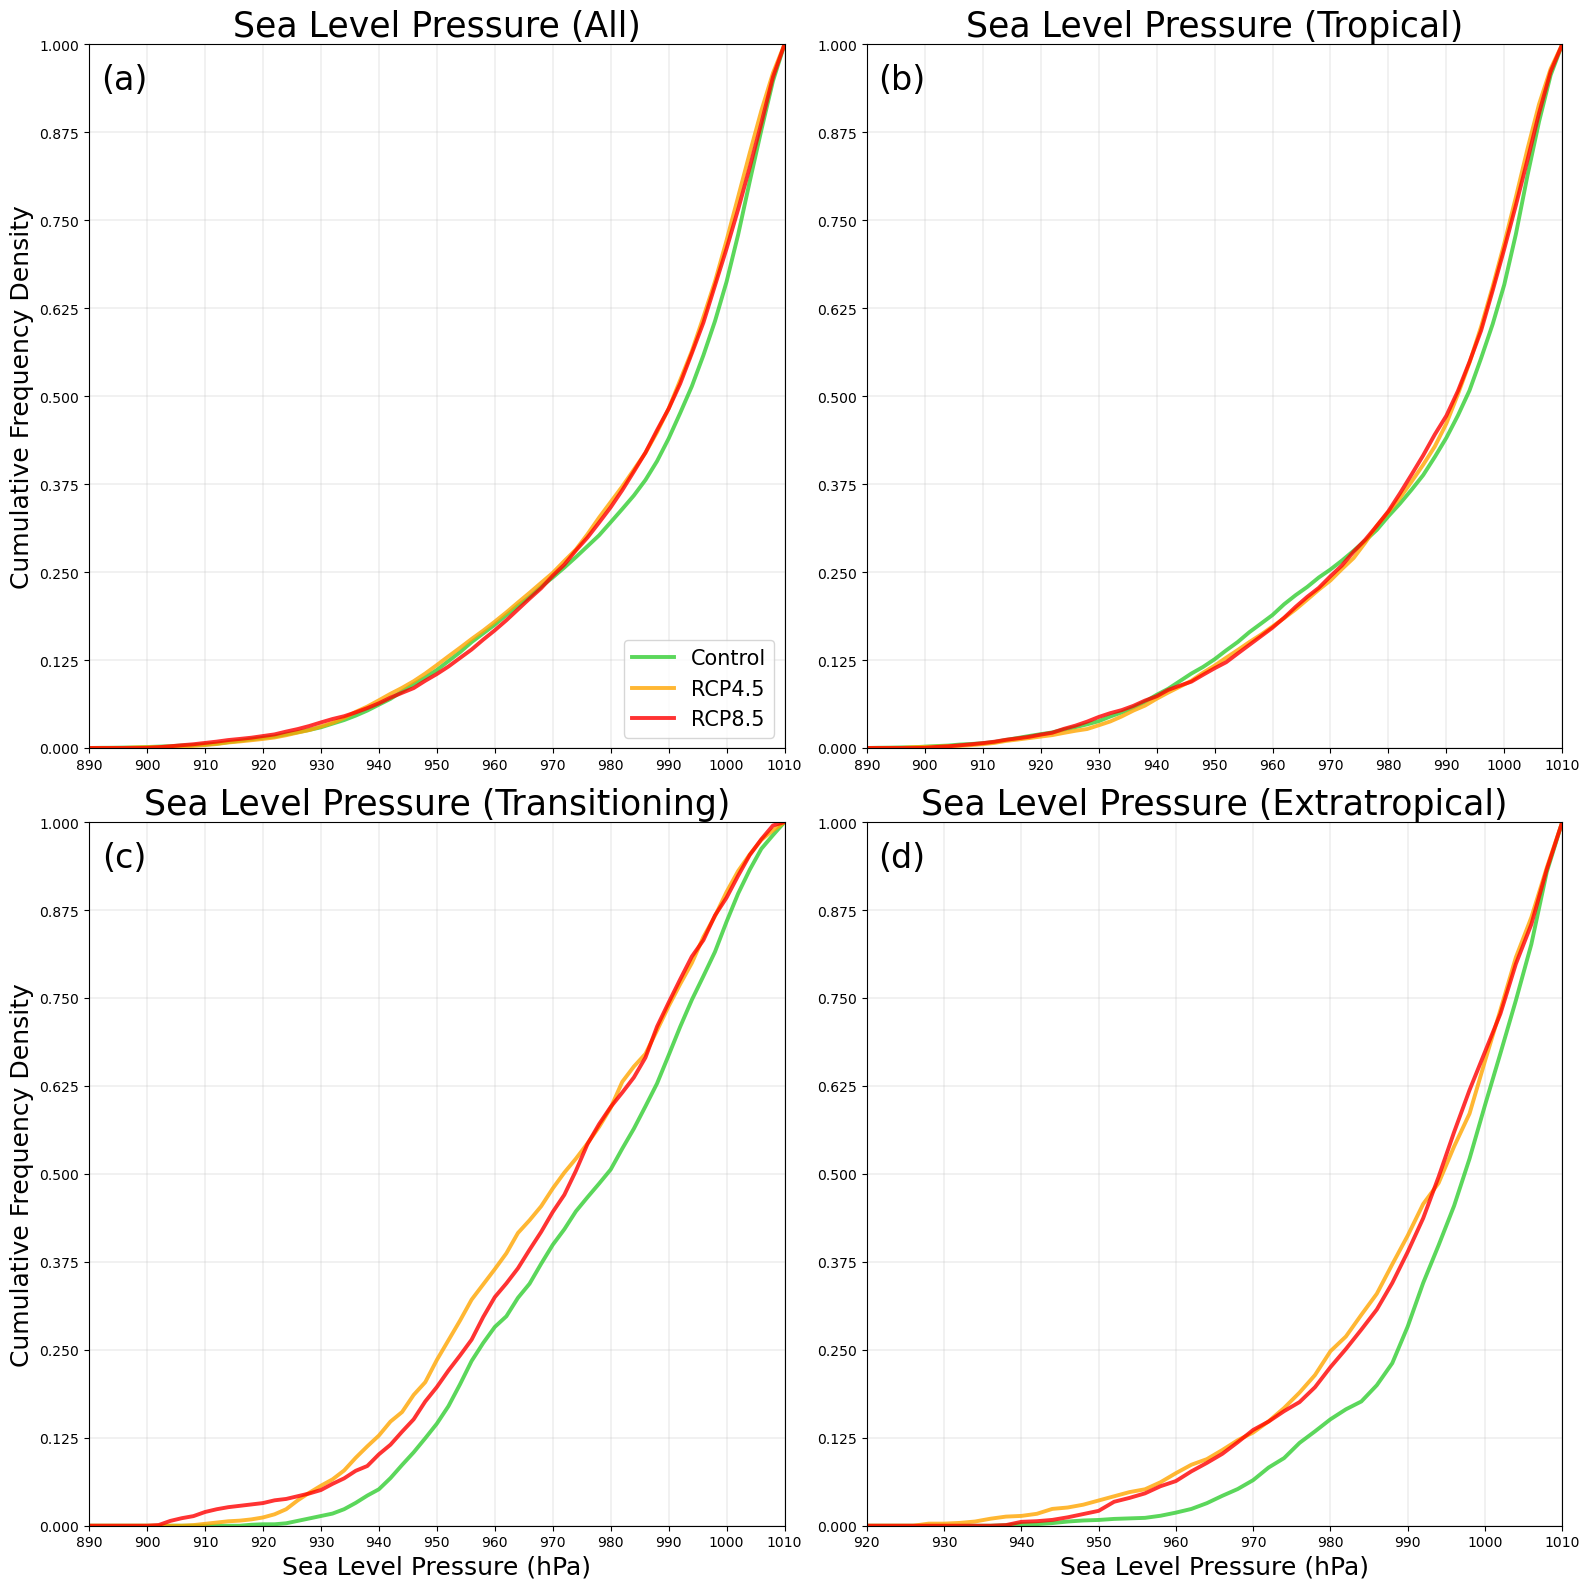

In [15]:
# Figure 7
# Sea Level Pressure at Each 6-Hourly Datapoints for Each Storm Phase
Var = "SLP(hPa)"
Var_Label = "Sea Level Pressure"
Horiz = False
Mins = [890, 890, 890, 920]
Maxes = [1010, 1010, 1010, 1010]
Bin_Widths = [2, 2, 2, 2]
Label_Widths = [10, 10, 10, 10]
Savefig = True
Figname = 'Figure_7.png'
Phase_Cum_Dist_Plot(Control_Data, RCP45_Data, RCP85_Data, Var, Var_Label, Horiz, \
Mins, Maxes, Bin_Widths, Label_Widths, Savefig, Figname)

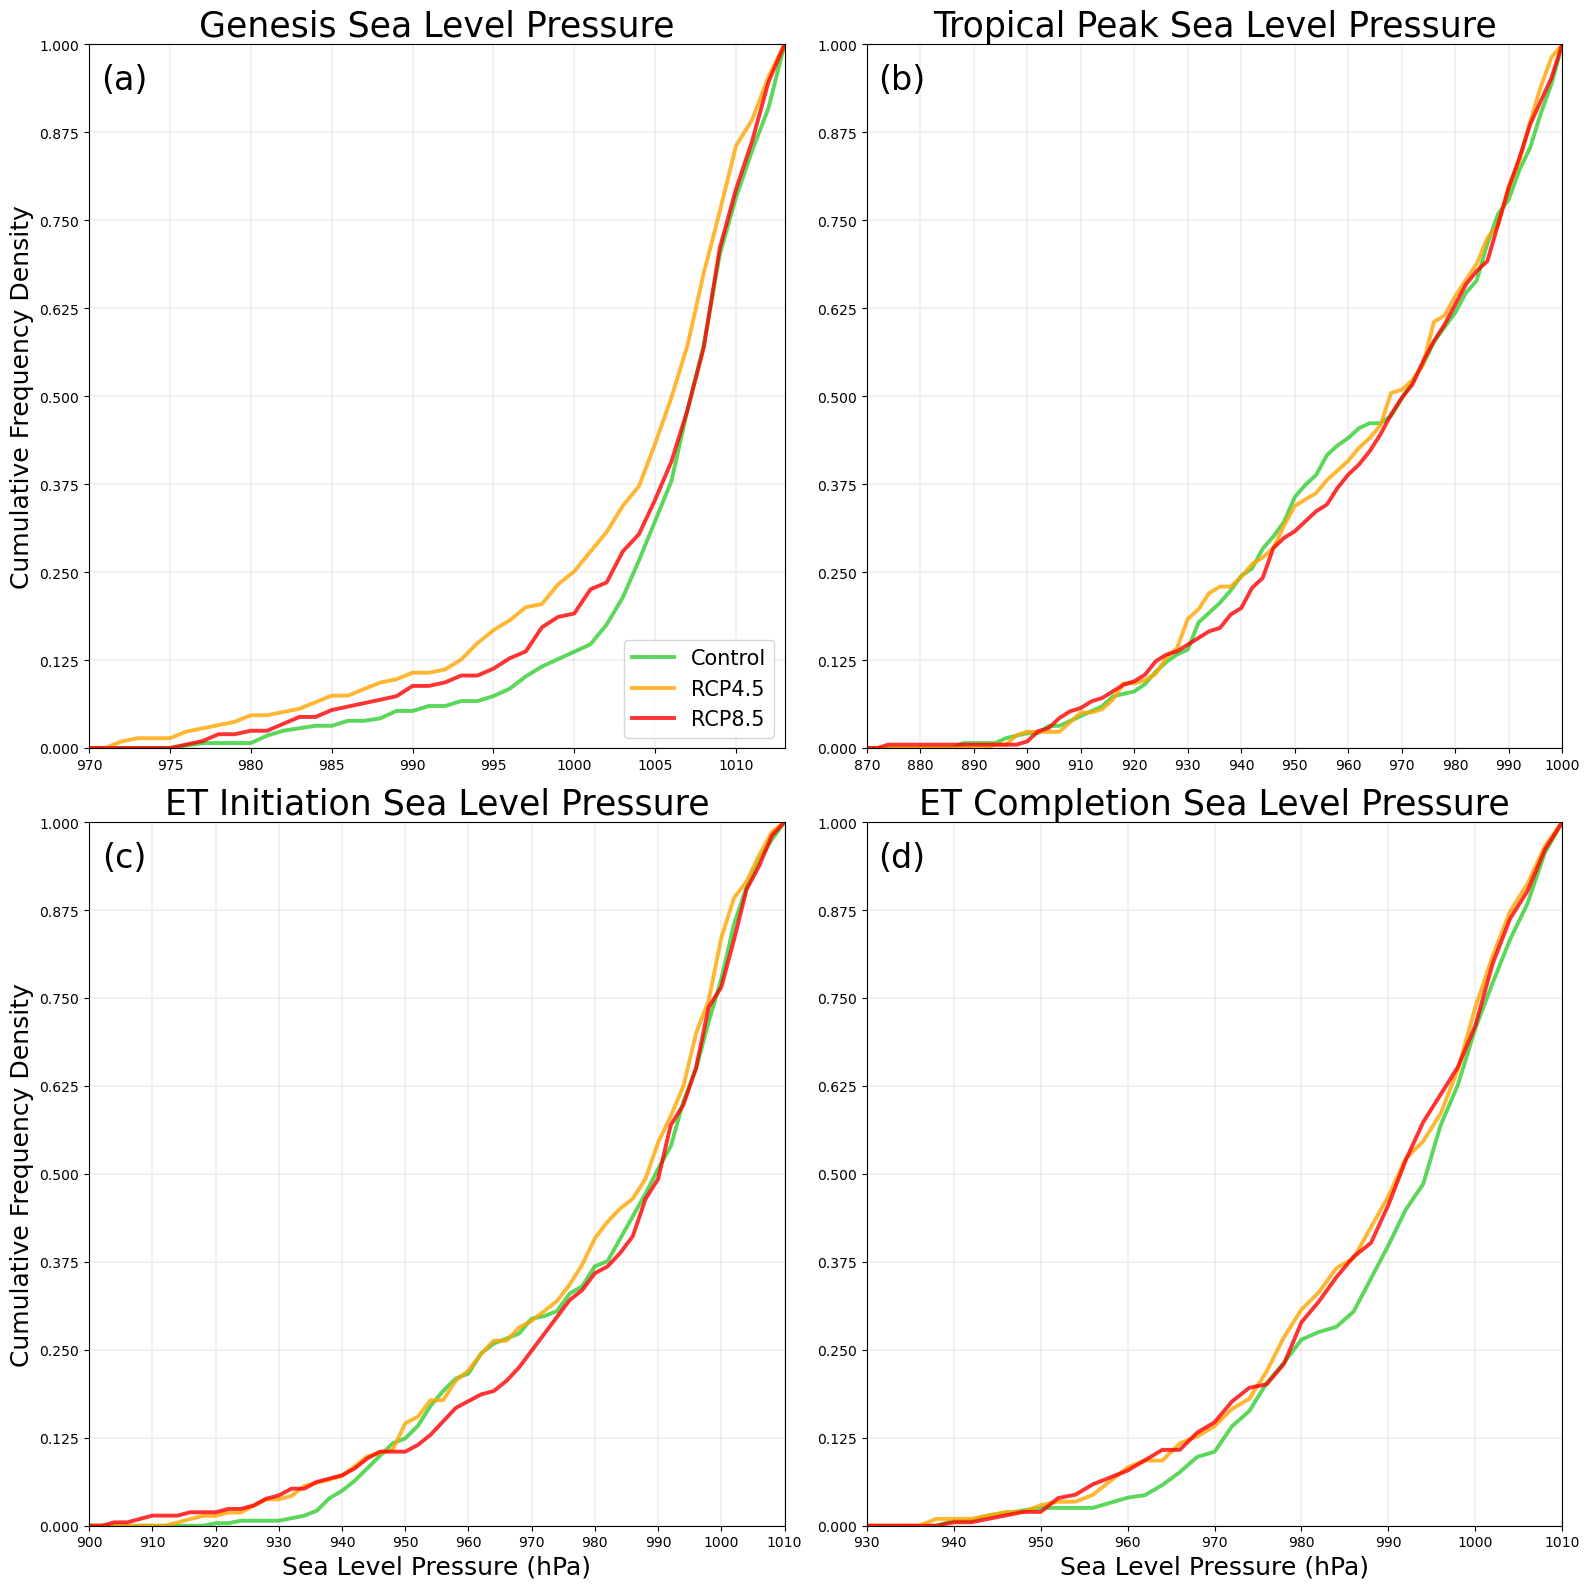

In [16]:
# Figure B7
# Sea Level Pressure at Genesis, Tropical Peak, ET Initiation and ET Completion
Var = "SLP"
Var_Label = "Sea Level Pressure"
Horiz = False
Mins = [970, 870, 900, 930]
Maxes = [1013, 1000, 1010, 1010]
Bin_Widths = [1, 2, 2, 2]
Label_Widths = [5, 10, 10, 10]
Savefig = True
Figname = 'Figure_B7.png'
ET_Cum_Dist_Plot(Control_ET, RCP45_ET, RCP85_ET, Var, Var_Label, Horiz, \
Mins, Maxes, Bin_Widths, Label_Widths, Savefig, Figname)

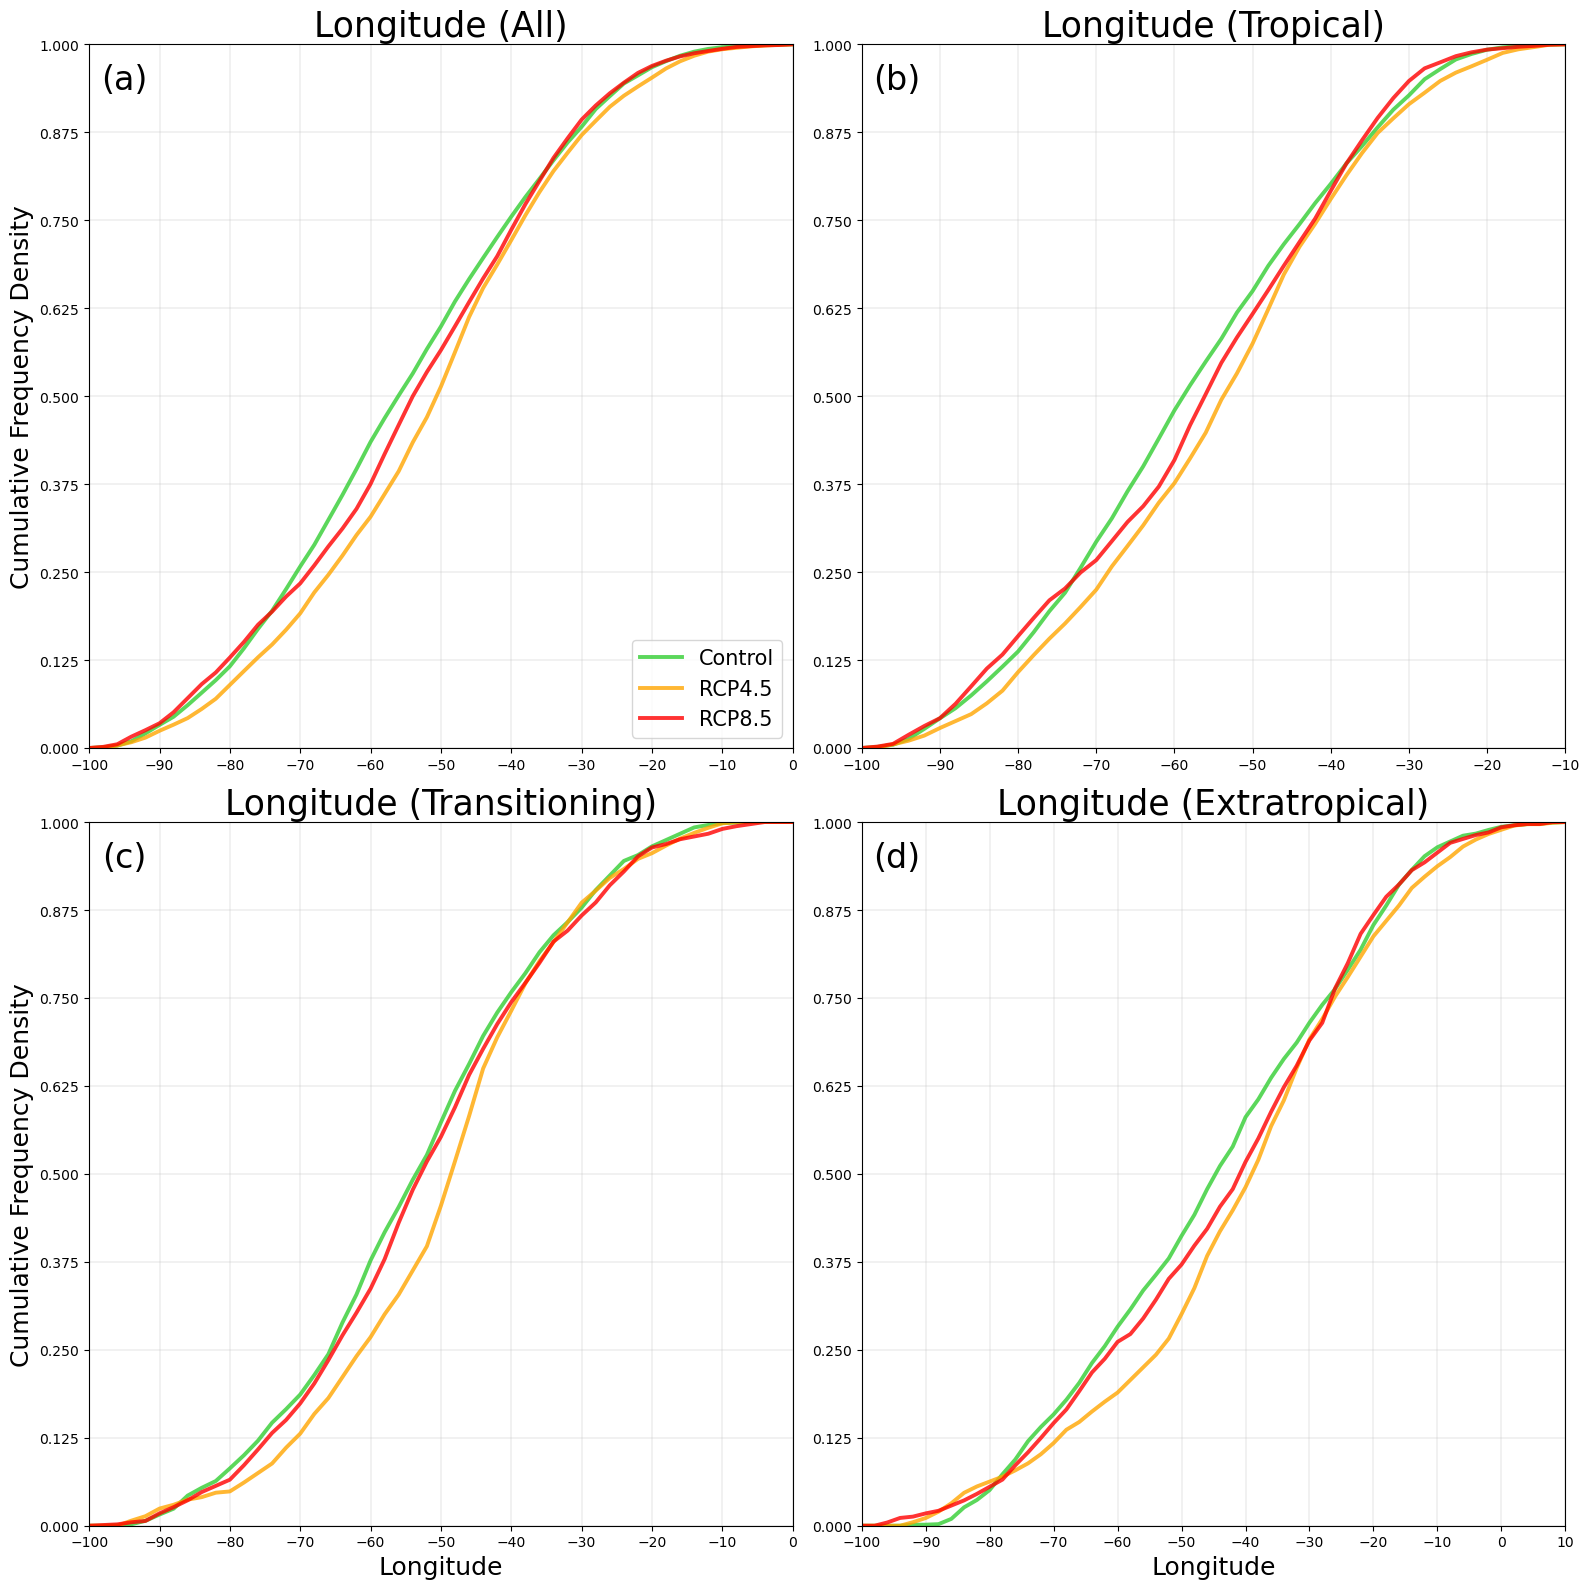

In [17]:
# Figure B3
# Longitude at Each 6-Hourly Datapoints for Each Storm Phase
Var = "Lon"
Var_Label = "Longitude"
Horiz = False
All_Min, Trop_Min, Trans_Min, Extra_Min = -100, -100, -100, -100
All_Max, Trop_Max, Trans_Max, Extra_Max = 0, -10, 0, 10
Mins = [-100, -100, -100, -100]
Maxes = [0, -10, 0, 10]
Bin_Widths = [2, 2, 2, 2]
Label_Widths = [10, 10, 10, 10]
Savefig = True
Figname = 'Figure_B3.png'
Phase_Cum_Dist_Plot(Control_Data, RCP45_Data, RCP85_Data, Var, Var_Label, Horiz, \
Mins, Maxes, Bin_Widths, Label_Widths, Savefig, Figname)

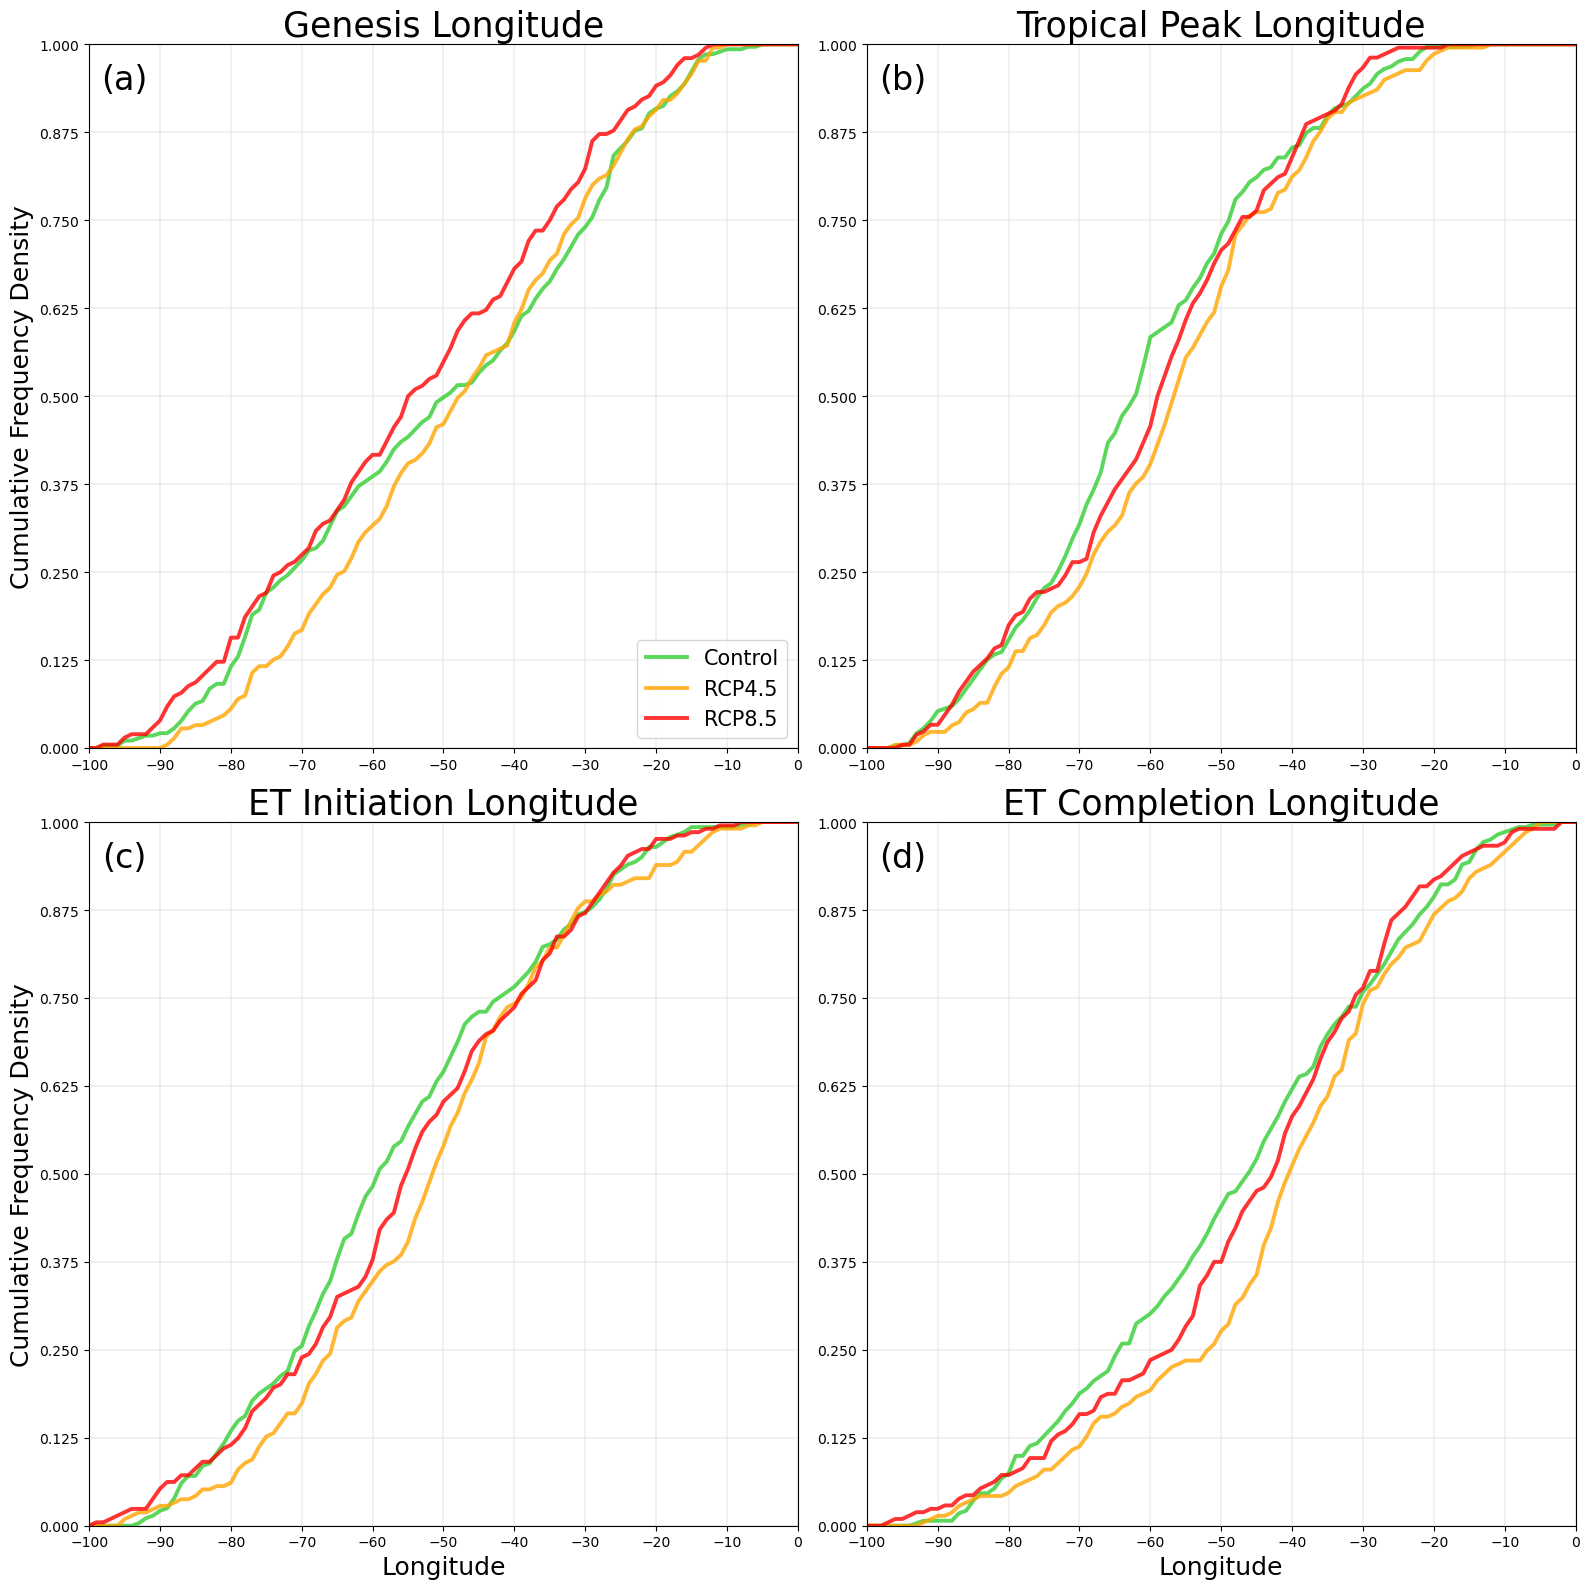

In [18]:
# Figure B5
# Longitude at Genesis, Tropical Peak, ET Initiation and ET Completion
Var = "Lon"
Var_Label = "Longitude"
Horiz = False
Mins = [-100, -100, -100, -100]
Maxes = [0, 0, 0, 0]
Bin_Widths = [1, 1, 1, 1]
Label_Widths = [10, 10, 10, 10]
Savefig = True
Figname = 'Figure_B5.png'
ET_Cum_Dist_Plot(Control_ET, RCP45_ET, RCP85_ET, Var, Var_Label, Horiz, \
Mins, Maxes, Bin_Widths, Label_Widths, Savefig, Figname)

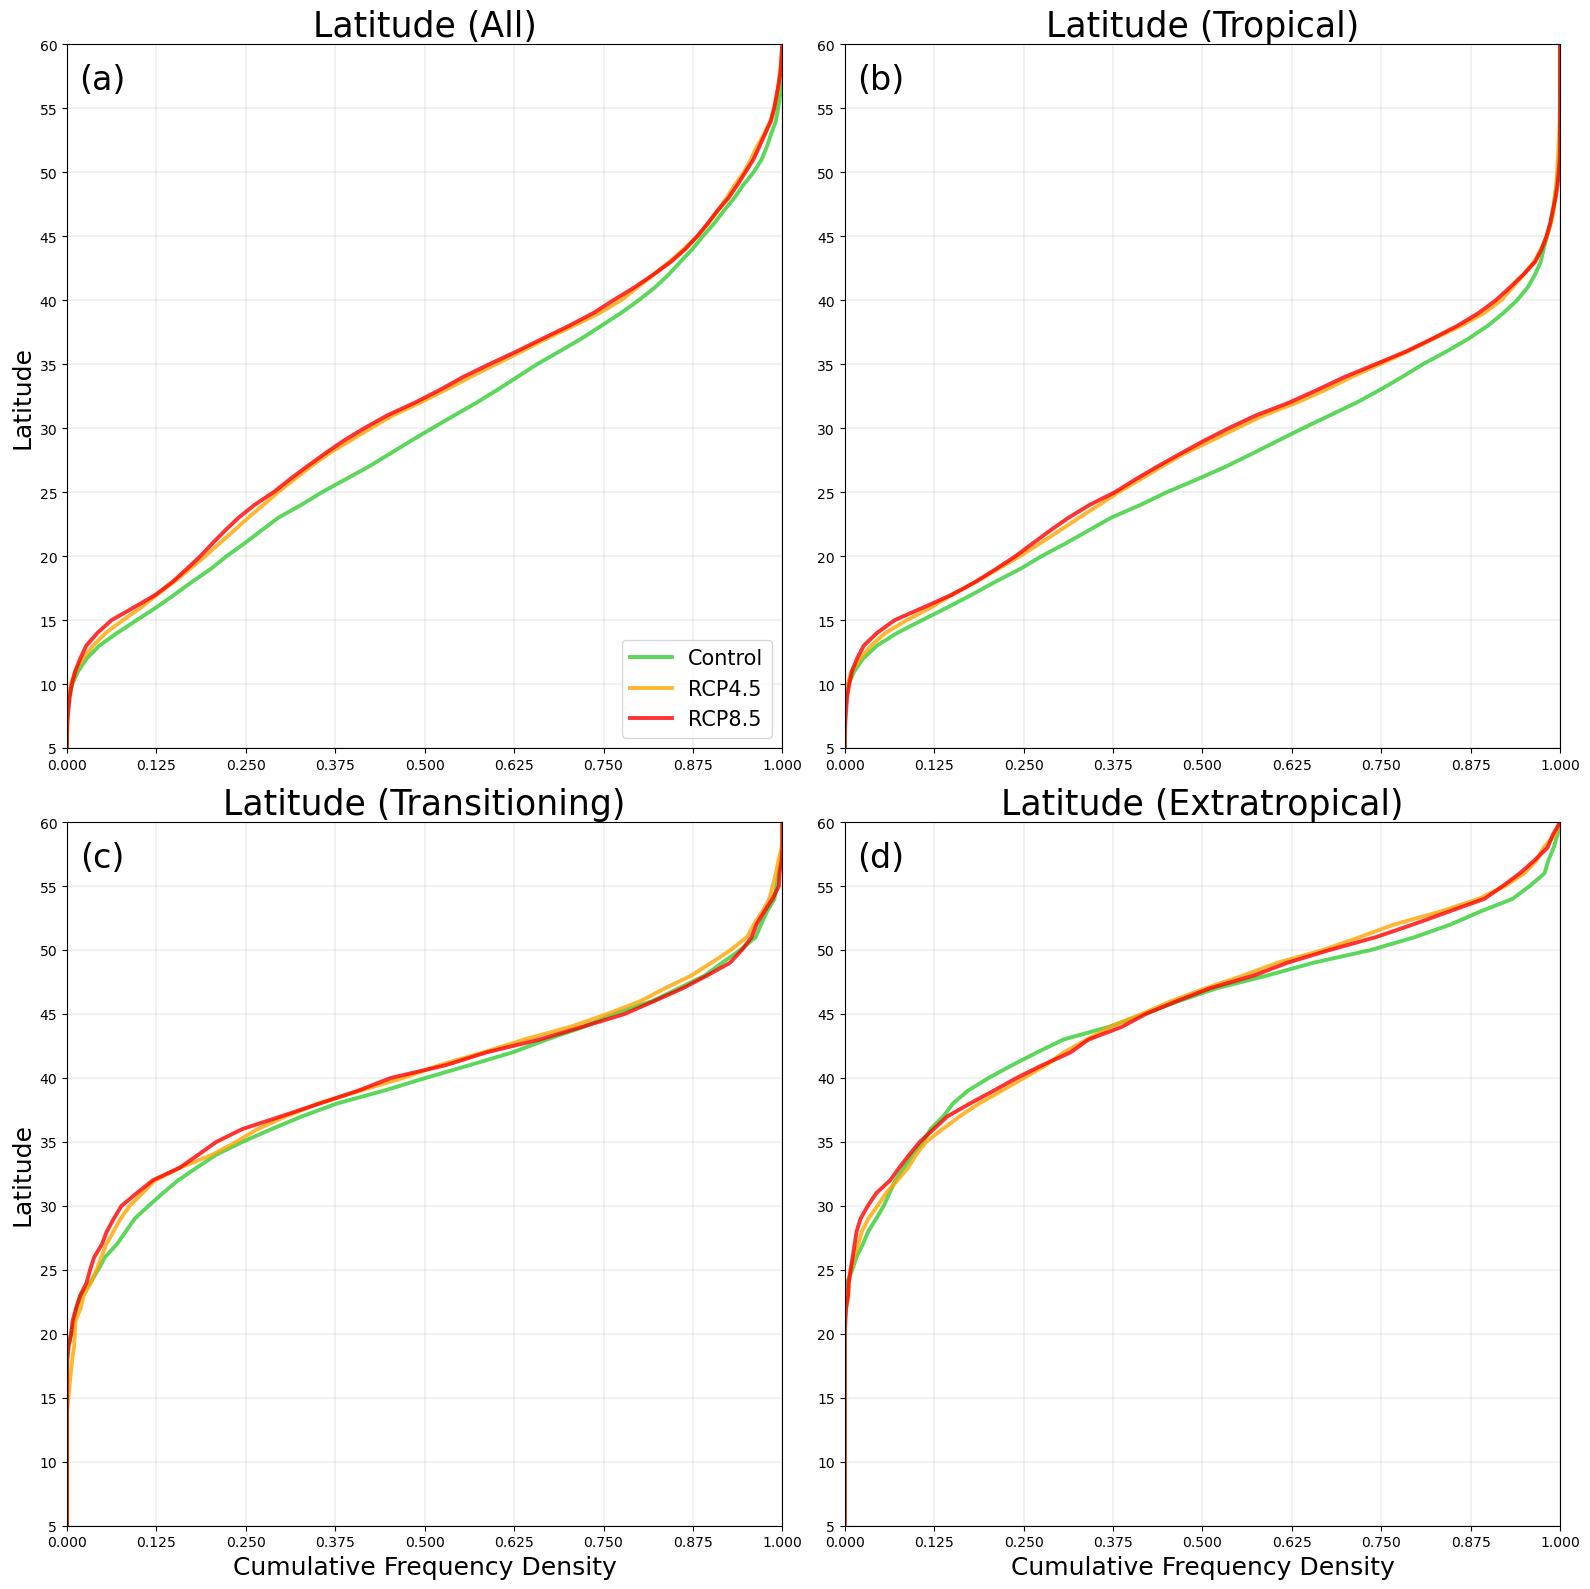

In [19]:
# Figure B4
# Latitude at Each 6-Hourly Datapoints for Each Storm Phase
Var = "Lat"
Var_Label = "Latitude"
Horiz = True
Mins = [5, 5, 5, 5]
Maxes = [60, 60, 60, 60]
Bin_Widths = [1, 1, 1, 1]
Label_Widths = [5, 5, 5, 5]
Savefig = True
Figname = 'Figure_B4.png'
Phase_Cum_Dist_Plot(Control_Data, RCP45_Data, RCP85_Data, Var, Var_Label, Horiz, \
Mins, Maxes, Bin_Widths, Label_Widths, Savefig, Figname)

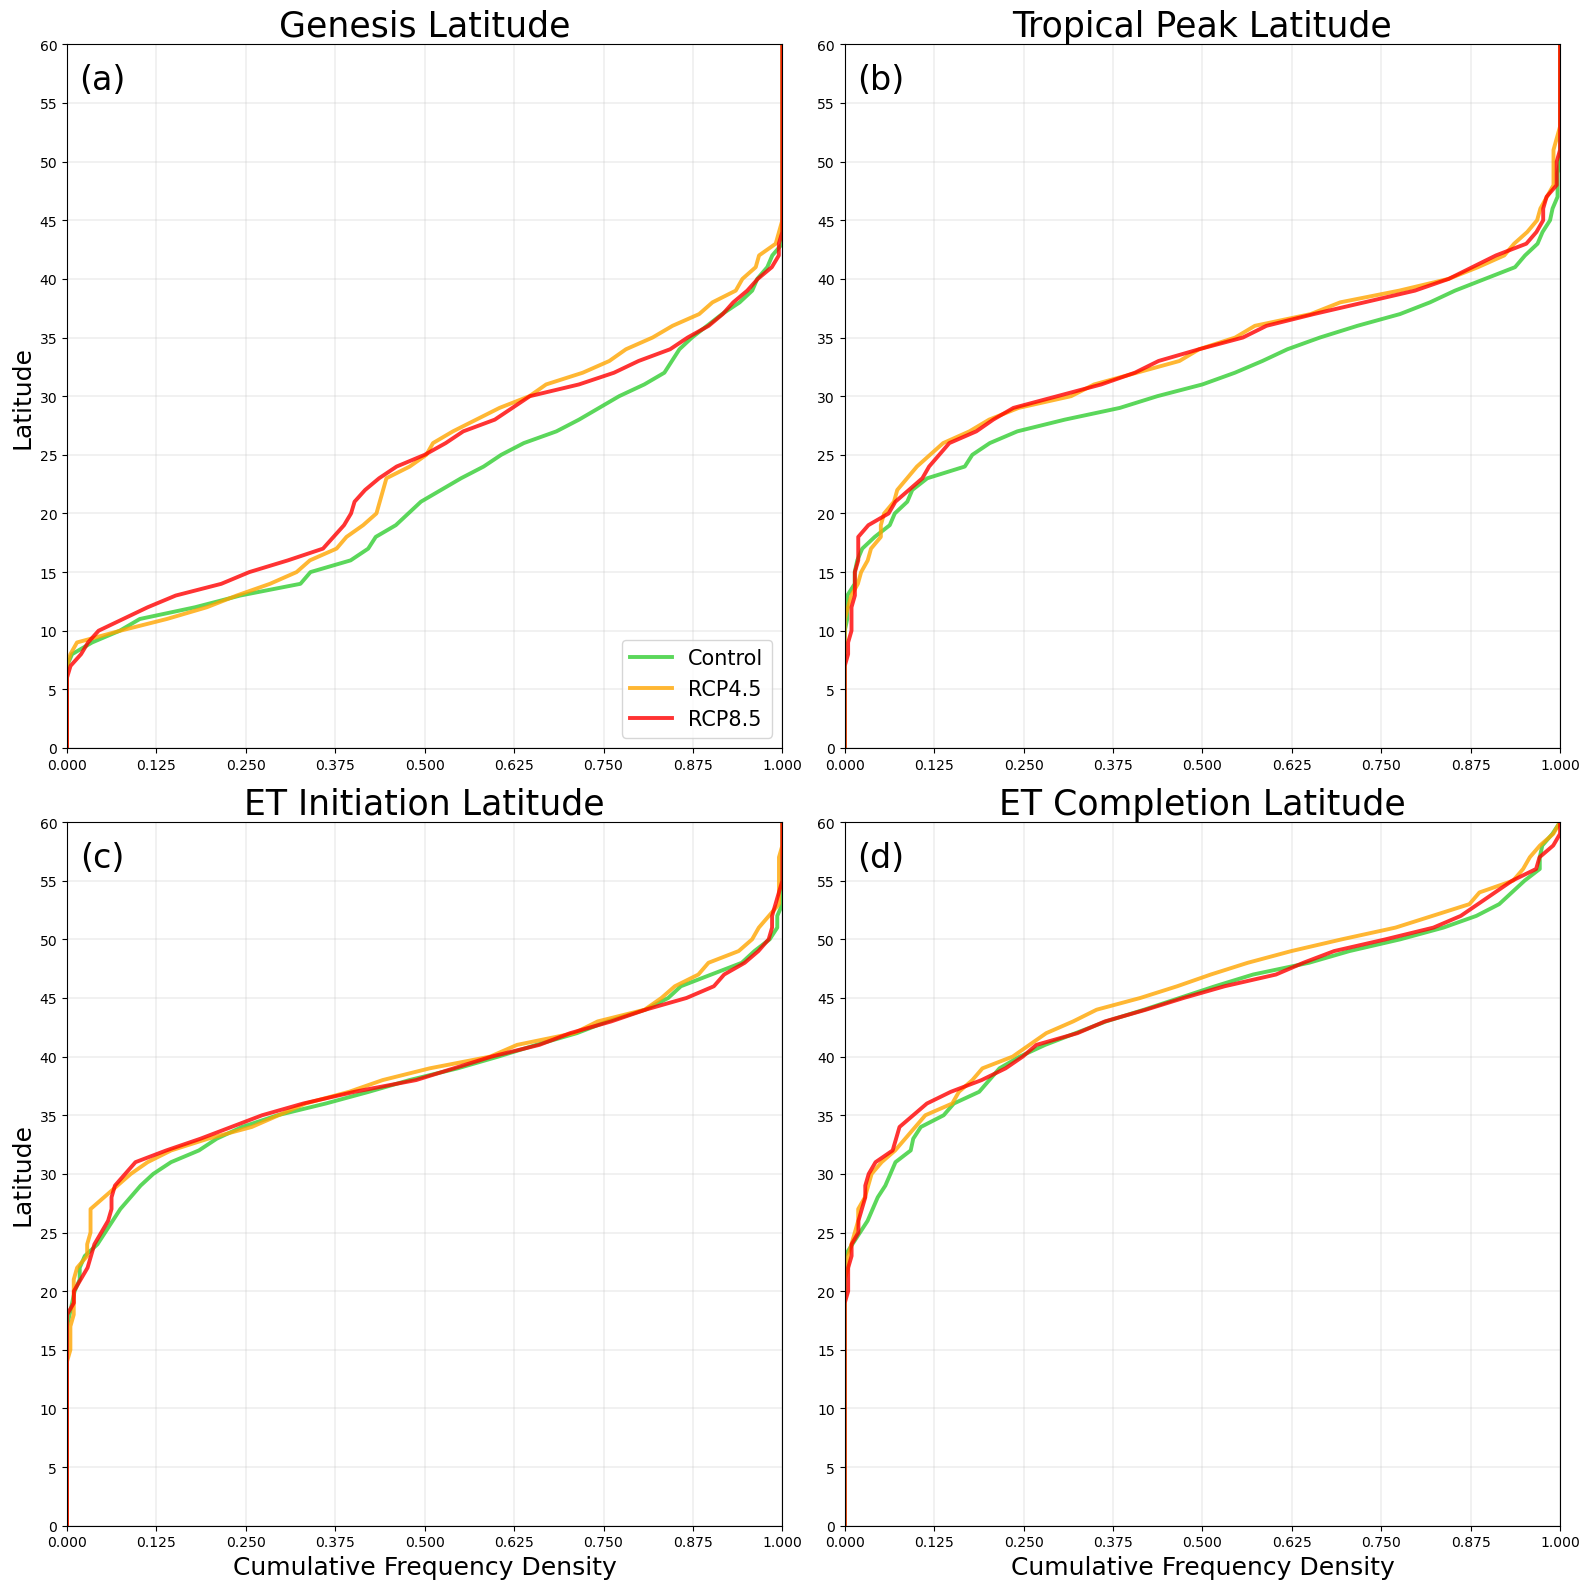

In [20]:
# Figure B6
# Latitude at Genesis, Tropical Peak, ET Initiation and ET Completion
Var = "Lat"
Var_Label = "Latitude"
Horiz = True
Mins = [0, 0, 0, 0]
Maxes = [60, 60, 60, 60]
Bin_Widths = [1, 1, 1, 1]
Label_Widths = [5, 5, 5, 5]
Savefig = True
Figname = 'Figure_B6.png'
ET_Cum_Dist_Plot(Control_ET, RCP45_ET, RCP85_ET, Var, Var_Label, Horiz, \
Mins, Maxes, Bin_Widths, Label_Widths, Savefig, Figname)